# Flood · Solar — M4 loss & metrics: annual loss distribution + EAL/PML/VaR (all three sub-perils)

**Peril:** Flood · **Asset:** Solar · **Layer:** M4 · sub-perils `riverine` + `pluvial` + `coastal` · the solar M4
combines all three (per JD-FL-17; **LA3 West Baton Rouge** is the all-three solar site, the wind analogue is Amazon).

**Magnitude metric:** flood **depth (ft above ground)** behind the M3 conditional losses — riverine/pluvial depth by
annual return period (10/25/50/100/500-yr), coastal surge depth by hurricane category per storm.

**Data source:** M3 conditional losses (the flood × solar curve over all three sub-perils), the riverine M2/M1 BLE
depths + flow-frequency rating, the coastal M1 catalog (`λ` + per-storm `event_family_id`), the hurricane × solar
wind leg (`data/hurricane/tc_m3_damage.parquet`), and **USGS STN high-water marks** for external validation.

**What this notebook does:** turns the M3 conditional losses into the **annual loss distribution** → **EAL / VaR /
PML / TVaR** (% of TIV + dollars), the same metric frame hail/wildfire/wind report (DD-4). Two frequency frames run
under one roof. **Inland** (riverine + pluvial) is annual-maximum Monte Carlo: each year draws one severity
`AEP ~ U(0,1)`, reads both sub-peril loss-exceedance curves comonotonically, and the year's loss = `max(riverine,
pluvial)` (per JD-FL-11). **Coastal** is compound-Poisson surge × hurricane wind, combining per subsystem
`max(wind_DR, surge_DR)` on `event_family_id` at the surge `λ` (per JD-FL-12). **Total** = inland + coastal as
independent streams. Sites carry whatever sub-perils they have (Elizabeth inland-only, Discovery coastal-only, LA3
all-three); absent sub-perils enter as 0. The riverine loss-exceedance curve is a 5-point RP curve — the 100/500-yr
points are BLE-anchored and the 10/25/50-yr points come from a regression flow-frequency rating anchored to both BLE
depths ([JD-FL-7](../../../../docs/plans/flood/decisions.md)/[JD-FL-8](../../../../docs/plans/flood/decisions.md)).

> **Honest:** PML@100/500-yr is anchored to real BLE; EAL rests on the measurement-anchored 10/25/50-yr depths
> (JD-FL-8). §2b shows how much that densification moves EAL. The curve is built generically from whatever RPs M3
> emits. Plan: [`m4_loss_metrics.md`](../../../../docs/plans/flood/m4_loss_metrics.md).

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "AGENTS.md").exists():
    ROOT = ROOT.parent
OUT = ROOT / "data" / "flood"

m3 = pd.DataFrame(json.loads((OUT / "flood_solar_m3_damage_manifest.json").read_text())["sites"])
sites = m3.groupby("name").agg(role=("role", "first"), tiv_usd=("tiv_usd", "first")).reset_index()
L = {(r["name"], r["sub_peril"], r["rp_years"]): r["cond_loss_frac_tiv"] for _, r in m3.iterrows()}   # keyed by sub_peril
# 10-yr riverine exposure now comes from M2's densified rows (Path 2: footprint reduction moved M1→M2, JD-FL-19)
_m2rows = json.loads((OUT / "flood_solar_m2_coupling_manifest.json").read_text())["rows"]
F10 = {r["name"]: r["exposure_fraction"] for r in _m2rows if r["sub_peril"] == "riverine" and r["rp_years"] == 10}
_cv = json.loads((OUT / "damage_curves" / "flood_solar_asset_capex_weighted.json").read_text())


def asset_dr(depth_ft):   # capex-weighted, anchored DR(0)=0 — same curve as M3
    tot = 0.0
    for c in _cv["subsystems"]:
        L_, k, x0 = c["L"], c["k"], c["x0_ft"]
        tot += c["capex_weight"] * max(L_ / (1 + np.exp(-k * (depth_ft - x0))) - L_ / (1 + np.exp(-k * (0 - x0))), 0)
    return tot


print("M3 conditional losses (input — riverine + pluvial):")
print(m3[["sub_peril", "name", "rp_years", "cond_loss_frac_tiv", "tiv_usd"]].to_string(index=False))
print("  10-yr riverine exposure (BLE 10% extent):", {n: f"{f*100:.0f}%" for n, f in F10.items()})

M3 conditional losses (input — riverine + pluvial):
sub_peril                                name  rp_years  cond_loss_frac_tiv   tiv_usd
 riverine                Hayhurst Texas Solar       100              0.0028  36778400
 riverine                Hayhurst Texas Solar       500              0.0060  36778400
 riverine               Elizabeth Solar Plant       100              0.0259 211772400
 riverine               Elizabeth Solar Plant       500              0.0424 211772400
 riverine LA3 West Baton Rouge Solar Facility       100              0.0565  74150000
 riverine LA3 West Baton Rouge Solar Facility       500              0.0974  74150000
 riverine               Elizabeth Solar Plant        10              0.0092 211772400
 riverine               Elizabeth Solar Plant        25              0.0149 211772400
 riverine               Elizabeth Solar Plant        50              0.0199 211772400
 riverine LA3 West Baton Rouge Solar Facility        10              0.0662  74150000
 r

## 1 · Per-sub-peril loss-exceedance curves (one per sub_peril × site)

Each `(site, sub_peril)` gets its own RP→loss curve from M3 — riverine (10/25/50/100/500-yr, BLE + regression-
densified) and pluvial (10/25/50/100/500-yr, Atlas-14). `ONSET_AEP` (10-yr) is the most-frequent mapped flood for
both; below it, no modelled loss. §2 **co-samples** both at one annual severity and takes the **worse** ([JD-FL-11](../../../../docs/plans/flood/decisions.md)).

In [2]:
ONSET_AEP = 0.10        # 10-yr: the most-frequent mapped flood (both sub-perils); more frequent → no modelled loss

RP_AVAIL = {}
for (nm, sp, rp) in L:
    RP_AVAIL.setdefault((nm, sp), []).append(rp)
for k in RP_AVAIL:
    RP_AVAIL[k].sort()
SUBPERILS = sorted({sp for (_, sp) in RP_AVAIL})   # ['pluvial', 'riverine']

def make_curve(name, sp):
    return [(round(1 / rp, 4), L[(name, sp, rp)]) for rp in RP_AVAIL[(name, sp)]]   # (AEP, loss), RP ascending

def loss_at_aep(aep, curve):
    aeps = np.array([c[0] for c in curve]); losses = np.array([c[1] for c in curve])
    x = np.log10(np.clip(aep, 1e-7, 1.0))
    xs = np.log10(aeps[::-1]); ys = losses[::-1]          # increasing x: rarest→onset
    loss = np.interp(x, xs, ys)                            # interpolate within [0.002, 0.1]
    # bounded extrapolation below the rarest anchor (continue the 100→500 log-AEP slope)
    slope = (losses[-1] - losses[-2]) / (np.log10(aeps[-1]) - np.log10(aeps[-2]))
    extrap = losses[-1] + slope * (x - np.log10(aeps[-1]))
    loss = np.where(x < np.log10(aeps[-1]), np.minimum(extrap, 3 * losses[-1]), loss)
    loss = np.where(aep >= ONSET_AEP, 0.0, loss)          # more frequent than onset → no damaging flood
    return np.clip(loss, 0.0, None)

for _, s in sites.iterrows():
    for sp in SUBPERILS:
        print(f"  {s['name']:24s} {sp:9s}: " + " · ".join(f"{int(1/a)}yr={l*100:.2f}%" for a, l in make_curve(s['name'], sp)))

  Elizabeth Solar Plant    pluvial  : 10yr=0.03% · 25yr=0.03% · 50yr=0.03% · 100yr=0.03% · 500yr=0.03%
  Elizabeth Solar Plant    riverine : 10yr=0.92% · 25yr=1.49% · 50yr=1.99% · 100yr=2.59% · 500yr=4.24%
  Hayhurst Texas Solar     pluvial  : 10yr=0.04% · 25yr=0.04% · 50yr=0.04% · 100yr=0.04% · 500yr=0.04%
  Hayhurst Texas Solar     riverine : 100yr=0.28% · 500yr=0.60%
  LA3 West Baton Rouge Solar Facility pluvial  : 10yr=0.26% · 25yr=0.26% · 50yr=0.26% · 100yr=0.26% · 500yr=0.26%
  LA3 West Baton Rouge Solar Facility riverine : 10yr=6.62% · 25yr=6.17% · 50yr=5.90% · 100yr=5.65% · 500yr=9.74%


## 2 · Monte-Carlo annual loss → **combine sub-perils** (co-sample, worse-wins) → metrics

Per simulated year draw **one** annual severity `AEP ~ U(0,1)` and read **both** sub-peril curves at it (comonotonic
— one storm drives both), then the year's flood loss = **max(riverine, pluvial)** ([JD-FL-11](../../../../docs/plans/flood/decisions.md)):
correlation-honest, no double-count. Metrics on the **combined** per-year vector (the joint — *not* summed marginals;
the convective_wind VaR lesson). Marginal per-sub-peril EALs kept for the breakdown.

In [3]:
N = 500_000
rng = np.random.default_rng(20260617)
RPS = [100, 250, 500]


def metrics_of(v):
    var99 = np.percentile(v, 99)
    return {"EAL": v.mean(), "VaR99": var99, "TVaR99": v[v >= var99].mean(),
            **{f"PML{T}": np.percentile(v, 100 * (1 - 1 / T)) for T in RPS}}


rows = []
vectors = {}        # combined per-year vector per site
marginal_eal = {}   # (site, sub_peril) -> marginal EAL %
for _, s in sites.iterrows():
    nm, tiv = s["name"], s["tiv_usd"]
    aep = rng.random(N)                                            # ONE severity per year → co-sample (JD-FL-11)
    per_sp = {sp: loss_at_aep(aep, make_curve(nm, sp)) for sp in SUBPERILS}
    combined = np.maximum.reduce(list(per_sp.values()))            # HEADLINE: worse-source-wins (φ=1; shared ground)
    vectors[nm] = combined
    for sp, v in per_sp.items():
        marginal_eal[(nm, sp)] = v.mean() * 100
    cm = metrics_of(combined)
    # recorded ENVELOPE only (NOT used downstream): additive-capped = upper bound (φ=0, fully-disjoint equipment)
    additive = np.minimum(sum(per_sp.values()), 1.0)              # min(TIV, Σ losses), co-sampled
    am = metrics_of(additive)
    rows.append({"name": nm, "role": s["role"], "tiv_usd": tiv,
                 "EAL_pct": cm["EAL"] * 100, "EAL_usd": cm["EAL"] * tiv,
                 "VaR99_pct": cm["VaR99"] * 100, "TVaR99_pct": cm["TVaR99"] * 100,
                 **{f"PML{T}_pct": cm[f"PML{T}"] * 100 for T in RPS},
                 **{f"PML{T}_usd": cm[f"PML{T}"] * tiv for T in RPS},
                 **{f"EAL_{sp}_pct": marginal_eal[(nm, sp)] for sp in SUBPERILS},
                 # envelope (sensitivity, recorded not used): EAL/PML500 under the additive-capped upper bound
                 "EAL_addUB_pct": am["EAL"] * 100, "PML500_addUB_pct": am["PML500"] * 100})
M = pd.DataFrame(rows)
print(M[["name", "EAL_pct", "VaR99_pct", "PML100_pct", "PML250_pct", "PML500_pct", "TVaR99_pct"]].round(3).to_string(index=False))
print("\ndollars:")
print(M[["name", "EAL_usd", "PML100_usd", "PML500_usd"]].round(0).to_string(index=False))
print("\nsub-peril EAL breakdown (% TIV) + the JD-FL-11 combine envelope (headline worse-wins → additive-capped upper bound):")
for _, r in M.iterrows():
    parts = " + ".join(f"{sp} {r[f'EAL_{sp}_pct']:.3f}" for sp in SUBPERILS)
    print(f"  {r['name']:24s} {parts}  | HEADLINE(worse-wins) {r['EAL_pct']:.3f}  envelope→ {r['EAL_pct']:.3f}–{r['EAL_addUB_pct']:.3f}")
print("  (headline = worse-wins φ=1, used downstream; additive-capped = φ=0 upper bound, recorded sensitivity only — JD-FL-11)")

                               name  EAL_pct  VaR99_pct  PML100_pct  PML250_pct  PML500_pct  TVaR99_pct
              Elizabeth Solar Plant    0.163      2.595       2.595       3.532       4.262       3.628
               Hayhurst Texas Solar    0.030      0.280       0.280       0.462       0.606       0.300
LA3 West Baton Rouge Solar Facility    0.653      6.606       6.606       8.072       9.904       8.444

dollars:
                               name  EAL_usd  PML100_usd  PML500_usd
              Elizabeth Solar Plant 344451.0   5495678.0   9026596.0
               Hayhurst Texas Solar  11110.0    102980.0    222999.0
LA3 West Baton Rouge Solar Facility 484465.0   4898499.0   7343891.0

sub-peril EAL breakdown (% TIV) + the JD-FL-11 combine envelope (headline worse-wins → additive-capped upper bound):
  Elizabeth Solar Plant    pluvial 0.003 + riverine 0.163  | HEADLINE(worse-wins) 0.163  envelope→ 0.163–0.166
  Hayhurst Texas Solar     pluvial 0.004 + riverine 0.030  | HEADLINE

## 2b · Densification sensitivity — regression-densified EAL vs an assumed-onset EAL

Sensitivity check on the riverine frequent region: the densified EAL rests on **regression-rating depths anchored to
both BLE depths** (10/25/50-yr, per JD-FL-8), versus an assumed-onset EAL that rests on a single flat **10-yr onset
depth** (`BLE exposure × Asset_DR(onset_ft)`) swept across a plausible onset-depth band. PML@100/500 are the real BLE
anchors and are unaffected. Because the M1 rating depths are near-invariant to channel slope, the densified EAL is
robust to the one free regression parameter.

In [4]:
def eal_assumed_onset(name, onset_ft, n=200_000):   # the pre-JD-FL-8 RIVERINE method, for comparison only
    curve = [(ONSET_AEP, F10.get(name, 0.0) * asset_dr(onset_ft)), (0.01, L[(name, "riverine", 100)]), (0.002, L[(name, "riverine", 500)])]
    return loss_at_aep(rng.random(n), curve).mean() * 100

cmp_rows = []
for _, s in sites.iterrows():
    nm = s["name"]
    dens_eal = loss_at_aep(rng.random(200_000), make_curve(nm, "riverine")).mean() * 100
    cmp_rows.append({"site": nm.split()[0], "riverine_EAL_densified%": round(dens_eal, 3),
                     **{f"assumed@{d}ft": round(eal_assumed_onset(nm, d), 3) for d in (0.0, 0.5, 1.0)}})
cmp = pd.DataFrame(cmp_rows)
print("Riverine EAL (% TIV): JD-FL-8 densified vs the old assumed-onset method (3 onset-depth guesses):")
print(cmp.to_string(index=False))
print("\n→ Densification replaces the onset guess with measurement-anchored 10/25/50-yr depths (riverine only).")

Riverine EAL (% TIV): JD-FL-8 densified vs the old assumed-onset method (3 onset-depth guesses):
     site  riverine_EAL_densified%  assumed@0.0ft  assumed@0.5ft  assumed@1.0ft
Elizabeth                    0.161          0.110          0.131          0.168
 Hayhurst                    0.030          0.013          0.013          0.013
      LA3                    0.654          0.248          0.339          0.525

→ Densification replaces the onset guess with measurement-anchored 10/25/50-yr depths (riverine only).


## 2c · Coastal compound — surge × hurricane WIND, per subsystem (JD-FL-12), for coastal-exposed solar sites

Per qualifying storm, combine the **surge** leg (this cell's coastal M3 `surge_loss`) and the **hurricane wind** leg
(`data/hurricane/tc_m3_damage`) **per subsystem**: `combined_DRₛ = max(wind_DRₛ, surge_DRₛ)`. Shared = PV_ARRAY +
SUBSTATION (both perils); wind-only = MOUNTING; surge-only = INVERTER/ELECTRICAL/CIVIL. Joined on `event_family_id`,
compound-Poisson MC at λ_surge. Coastal-exposed solar sites = **Discovery** + the all-three **LA3**.

In [5]:
TC = ROOT / "data" / "hurricane"
TIV_W = {"PV_ARRAY": 0.33, "MOUNTING": 0.13, "SUBSTATION": 0.075, "INVERTER": 0.08,
         "ELECTRICAL": 0.10, "CIVIL_INFRA": 0.08, "SCADA": 0.03, "BOS_REMAIN": 0.175}   # canonical solar split (02_coastal_compound)
SHARED = ["PV_ARRAY", "SUBSTATION"]
WIND_C = {"PV_ARRAY": {"L": 0.85, "k": 0.055, "x0": 148}, "MOUNTING": {"L": 0.80, "k": 0.055, "x0": 120},
          "SUBSTATION": {"L": 0.80, "k": 0.040, "x0": 120}}                              # 3-s gust mph
SURGE_C = {"PV_ARRAY": {"L": 0.90, "k": 1.8, "x0": 2.5}, "SUBSTATION": {"L": 0.95, "k": 2.5, "x0": 1.5},
           "INVERTER": {"L": 0.95, "k": 3.5, "x0": 0.75}, "ELECTRICAL": {"L": 0.55, "k": 1.0, "x0": 3.0},
           "CIVIL_INFRA": {"L": 0.70, "k": 1.2, "x0": 2.0}}                              # depth ft
def _cdr(c, x):
    raw = c["L"] / (1 + np.exp(-c["k"] * (x - c["x0"]))); base = c["L"] / (1 + np.exp(-c["k"] * (0 - c["x0"])))
    return np.clip((raw - base) / (1 - base), 0, 1)
def cp_metrics(annual, tiv):
    return {"EAL_pct": annual.mean()/tiv*100, "PML100_pct": np.quantile(annual, 0.99)/tiv*100,
            "PML250_pct": np.quantile(annual, 0.996)/tiv*100, "PML500_pct": np.quantile(annual, 0.998)/tiv*100}

cman = json.loads((OUT / "flood_coastal_m1_catalog_manifest.json").read_text())
coastal_solar = [c for c in cman["sites"] if c["asset"] == "solar" and c["exposed"]]
wind_leg = pd.read_parquet(TC / "tc_m3_damage.parquet")
compound_metrics, coastal_vectors = {}, {}
for cs in coastal_solar:
    cslug, nm, lam = cs["slug"], cs["name"], cs["lambda_per_yr"]
    surge = pd.read_parquet(OUT / f"{cslug}_flood_solar_coastal_m3_surge_loss.parquet")
    TIV = float(surge["tiv_usd"].iloc[0])
    w = wind_leg[wind_leg.site == nm][["event_family_id", "gust_3s_mph"]]
    df = w.merge(surge[["event_family_id", "conditional_depth_ft", "exposure_fraction"]], on="event_family_id", how="left")
    df["conditional_depth_ft"] = df["conditional_depth_ft"].fillna(0.0); df["exposure_fraction"] = df["exposure_fraction"].fillna(0.0)
    g, d, ex = df["gust_3s_mph"].values, df["conditional_depth_ft"].values, df["exposure_fraction"].values
    wind_DR = {s: _cdr(WIND_C[s], g) for s in WIND_C}                 # PV, MOUNTING, SUBSTATION
    surge_DR = {s: ex * _cdr(SURGE_C[s], d) for s in SURGE_C}         # exposure-scaled (areal surge)
    def asset_loss(mode):
        loss = np.zeros(len(df))
        for sub, wt in TIV_W.items():
            wd = wind_DR.get(sub, 0.0); sd = surge_DR.get(sub, 0.0)
            dri = wd if mode == "wind" else sd if mode == "surge" else np.maximum(wd, sd)   # headline = max per subsystem
            loss = loss + wt * np.asarray(dri)
        return loss * TIV
    df["wind_loss"], df["surge_loss"], df["compound_loss"] = asset_loss("wind"), asset_loss("surge"), asset_loss("headline")
    counts = rng.poisson(lam, N); n_ev = int(counts.sum())           # ONE shared storm draw (per-realization compound ≥ each leg)
    idx = rng.integers(0, len(df), n_ev); yr = np.repeat(np.arange(N), counts)
    annual_of = lambda col: np.bincount(yr, weights=df[col].values[idx], minlength=N)
    coa_annual = annual_of("compound_loss"); coastal_vectors[nm] = coa_annual / TIV
    compound_metrics[nm] = {"lambda_per_yr": lam, "n_storms_wind": int(len(df)),
                            "wind_only": cp_metrics(annual_of("wind_loss"), TIV), "surge_only": cp_metrics(annual_of("surge_loss"), TIV),
                            "compound": cp_metrics(coa_annual, TIV)}
    cm = compound_metrics[nm]
    print(f"{nm} — coastal compound (λ={lam:.4f}/yr, {len(df)} wind storms): wind-only {cm['wind_only']['EAL_pct']:.3f}% · "
          f"surge-only {cm['surge_only']['EAL_pct']:.3f}% · COMPOUND {cm['compound']['EAL_pct']:.3f}% · PML500 {cm['compound']['PML500_pct']:.2f}%")

Discovery Solar Center — coastal compound (λ=0.0289/yr, 280 wind storms): wind-only 0.251% · surge-only 0.140% · COMPOUND 0.338% · PML500 38.72%
LA3 West Baton Rouge Solar Facility — coastal compound (λ=0.0173/yr, 51 wind storms): wind-only 0.093% · surge-only 0.020% · COMPOUND 0.107% · PML500 7.22%


## 2d · Total flood per site = inland (annual-max) + coastal (compound-Poisson), independent streams (JD-FL-17)

Inland-only sites (Elizabeth) keep their inland total; coastal-only (Discovery) is `0 + coastal`; the all-three
**LA3** gains both. Absent sub-perils enter as 0 — the same general engine as wind.

In [6]:
total_metrics = {}
for nm in sorted(set(sites["name"]) | set(coastal_vectors)):
    inland = vectors.get(nm, np.zeros(N)); coa = coastal_vectors.get(nm, np.zeros(N)); tot = inland + coa
    total_metrics[nm] = {"inland_eal_pct": inland.mean()*100, "coastal_eal_pct": coa.mean()*100,
                         "EAL_pct": tot.mean()*100, "PML100_pct": np.percentile(tot, 99)*100,
                         "PML250_pct": np.percentile(tot, 99.6)*100, "PML500_pct": np.percentile(tot, 99.8)*100}
    vectors[nm + "__total"] = tot
print("\ntotal flood (inland + coastal), % of TIV:")
for nm, tm in total_metrics.items():
    print(f"  {nm:24s} inland {tm['inland_eal_pct']:.3f} + coastal {tm['coastal_eal_pct']:.3f} = "
          f"TOTAL EAL {tm['EAL_pct']:.3f}% · PML100 {tm['PML100_pct']:.2f}% · PML500 {tm['PML500_pct']:.2f}%")


total flood (inland + coastal), % of TIV:
  Discovery Solar Center   inland 0.000 + coastal 0.338 = TOTAL EAL 0.338% · PML100 9.35% · PML500 38.72%
  Elizabeth Solar Plant    inland 0.163 + coastal 0.000 = TOTAL EAL 0.163% · PML100 2.60% · PML500 4.26%
  Hayhurst Texas Solar     inland 0.030 + coastal 0.000 = TOTAL EAL 0.030% · PML100 0.28% · PML500 0.61%
  LA3 West Baton Rouge Solar Facility inland 0.653 + coastal 0.107 = TOTAL EAL 0.761% · PML100 7.00% · PML500 12.24%


## 3 · Plots — loss-exceedance curve + annual-loss distribution

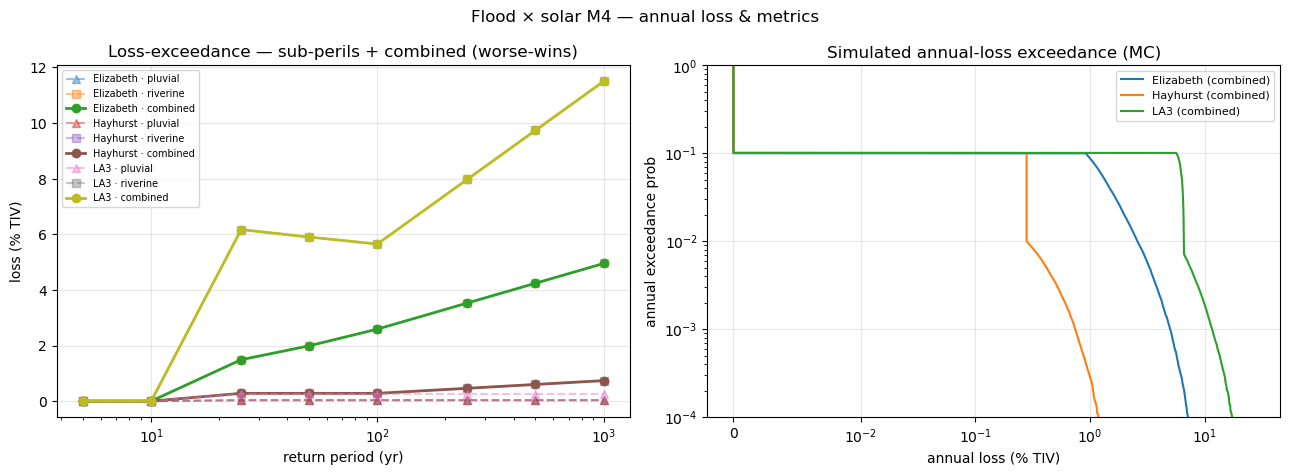

In [7]:
import matplotlib.pyplot as plt

fig, (axC, axH) = plt.subplots(1, 2, figsize=(13, 4.8))
Ts = np.array([5, 10, 25, 50, 100, 250, 500, 1000])
for _, s in sites.iterrows():
    nm = s["name"]
    per_sp = {sp: loss_at_aep(1 / Ts, make_curve(nm, sp)) for sp in SUBPERILS}
    combined = np.maximum.reduce(list(per_sp.values())) * 100
    for sp, v in per_sp.items():
        axC.plot(Ts, v * 100, "^--" if sp == "pluvial" else "s--", alpha=0.45, label=f"{nm.split()[0]} · {sp}")
    axC.plot(Ts, combined, "o-", lw=2, label=f"{nm.split()[0]} · combined")
    axH.plot(np.sort(vectors[nm])[::-1] * 100, np.arange(1, N + 1) / N, label=f"{nm.split()[0]} (combined)")
axC.set_xscale("log"); axC.set_xlabel("return period (yr)"); axC.set_ylabel("loss (% TIV)")
axC.set_title("Loss-exceedance — sub-perils + combined (worse-wins)"); axC.legend(fontsize=7); axC.grid(alpha=0.3)
axH.set_xscale("symlog", linthresh=0.01); axH.set_yscale("log"); axH.set_ylim(1e-4, 1)
axH.set_xlabel("annual loss (% TIV)"); axH.set_ylabel("annual exceedance prob")
axH.set_title("Simulated annual-loss exceedance (MC)"); axH.legend(fontsize=8); axH.grid(alpha=0.3)
fig.suptitle("Flood × solar M4 — annual loss & metrics")
fig.tight_layout()
plt.show()

## 4 · Known-answer checks (basics-spot-on)

- **Combine frame check (JD-FL-11):** the combined is co-sampled worse-wins, so its **PML@T reproduces the *worse*
  sub-peril's Lₜ** — `PML_T(combined) ≈ max_sp L(site, sp, T)` by construction.
- **Monotone:** PML rises with RP. **Combined ≥ each marginal.** **Contrast:** Elizabeth ≫ Hayhurst. EAL ≪ PML.

In [8]:
eliz = M[M.name == "Elizabeth Solar Plant"].iloc[0]
hay = M[M.name == "Hayhurst Texas Solar"].iloc[0]
maxL = lambda nm, T: max(L[(nm, sp, T)] for sp in SUBPERILS)
assert abs(eliz["PML100_pct"] / 100 - maxL("Elizabeth Solar Plant", 100)) < 0.003, "PML100 must reproduce max-sub-peril L100 (combine frame check)"
assert abs(eliz["PML500_pct"] / 100 - maxL("Elizabeth Solar Plant", 500)) < 0.004, "PML500 must reproduce max-sub-peril L500"
assert eliz["PML500_pct"] >= eliz["PML250_pct"] >= eliz["PML100_pct"] >= eliz["EAL_pct"] > 0, "metrics must be monotone & positive"
assert eliz["EAL_pct"] >= max(eliz[f"EAL_{sp}_pct"] for sp in SUBPERILS) - 1e-9, "combined EAL ≥ every marginal (worse-wins)"
assert eliz["EAL_pct"] > hay["EAL_pct"], "Elizabeth should dominate Hayhurst"
print(f"✓ combine frame check: Elizabeth PML100 {eliz['PML100_pct']:.2f}% ≈ max-sp L100 {maxL('Elizabeth Solar Plant',100)*100:.2f}% | PML500 {eliz['PML500_pct']:.2f}% ≈ {maxL('Elizabeth Solar Plant',500)*100:.2f}%")
print(f"✓ Elizabeth: EAL {eliz['EAL_pct']:.3f}% < PML100 {eliz['PML100_pct']:.2f}% < PML500 {eliz['PML500_pct']:.2f}% TIV (monotone), ≥ each marginal")
print(f"✓ Elizabeth EAL {eliz['EAL_pct']:.3f}% > Hayhurst EAL {hay['EAL_pct']:.3f}% (contrast)")
for nm, cm in compound_metrics.items():
    assert cm["compound"]["EAL_pct"] >= cm["surge_only"]["EAL_pct"] - 1e-9, "compound ≥ surge-only (per-subsystem max)"
    assert cm["compound"]["EAL_pct"] >= cm["wind_only"]["EAL_pct"] - 1e-9, "compound ≥ wind-only (per-subsystem max)"
    assert total_metrics[nm]["EAL_pct"] >= cm["compound"]["EAL_pct"] - 1e-9, "total ≥ coastal compound (inland adds)"
    print(f"✓ COASTAL COMPOUND {nm}: compound EAL {cm['compound']['EAL_pct']:.3f}% ≥ max(wind {cm['wind_only']['EAL_pct']:.3f}%, "
          f"surge {cm['surge_only']['EAL_pct']:.3f}%) — per-subsystem max on the joined storm stream (JD-FL-12)")
print("✓ M4 known-answer checks pass (riverine + pluvial + coastal compound + total).")

✓ combine frame check: Elizabeth PML100 2.60% ≈ max-sp L100 2.59% | PML500 4.26% ≈ 4.24%
✓ Elizabeth: EAL 0.163% < PML100 2.60% < PML500 4.26% TIV (monotone), ≥ each marginal
✓ Elizabeth EAL 0.163% > Hayhurst EAL 0.030% (contrast)
✓ COASTAL COMPOUND Discovery Solar Center: compound EAL 0.338% ≥ max(wind 0.251%, surge 0.140%) — per-subsystem max on the joined storm stream (JD-FL-12)
✓ COASTAL COMPOUND LA3 West Baton Rouge Solar Facility: compound EAL 0.107% ≥ max(wind 0.093%, surge 0.020%) — per-subsystem max on the joined storm stream (JD-FL-12)
✓ M4 known-answer checks pass (riverine + pluvial + coastal compound + total).


## 4b · External validation — observed flood depths (USGS high-water marks)

Beyond the internal frame checks: do the modeled depths match a **real flood**? USGS surveyed high-water marks after
the **Aug-2016 Louisiana flood**; we compare the proving site's modeled depth-at-RP against the observed
height-above-ground near the site. Expectation: our **feet-scale** depths fall **inside** the observed range — a
real-data regime check (not a to-the-inch calibration; the marks are regional, ~25–45 km out, many near channels).

In [9]:
import math
import requests

prov = pd.DataFrame(json.loads((OUT / "flood_solar_m0_sites.json").read_text())["sites"])
prov = prov[prov.role.str.contains("proving")].iloc[0]
# the HWM are river/channel flood marks → compare to the RIVERINE modeled depths
_rivd = m3[(m3.name == prov["name"]) & (m3.sub_peril == "riverine")]["conditional_depth_m"]
model_ft = sorted((_rivd / 0.3048).round(2).tolist())
validation = {"source": "USGS STN high-water marks", "note": "not run"}
try:
    hwm = requests.get("https://stn.wim.usgs.gov/STNServices/HWMs/FilteredHWMs.json",
                       params={"States": prov["state"]}, timeout=40).json()
    near = sorted(h["height_above_gnd"] for h in hwm
                  if h.get("latitude") and h.get("longitude") and h.get("height_above_gnd") not in (None, "")
                  and math.hypot(h["latitude"] - prov["lat"], h["longitude"] - prov["lon"]) < 0.45)
    if near:
        lo, med, hi = near[0], near[len(near) // 2], near[-1]
        inside = (lo - 0.5) <= min(model_ft) and max(model_ft) <= (hi + 0.5)
        validation = {"source": "USGS STN high-water marks (regional, Aug-2016 LA flood era)", "n_marks": len(near),
                      "observed_ft": {"min": round(lo, 2), "median": round(med, 2), "max": round(hi, 2)},
                      "modeled_depth_ft": model_ft, "model_within_observed": bool(inside)}
        print(f"observed flood marks near {prov['name']} (n={len(near)}): {lo:.1f} / median {med:.1f} / {hi:.1f} ft above ground")
        print(f"modeled depths (10→500-yr): {model_ft} ft")
        assert inside, "modeled depths fall outside the observed flood-mark range — review"
        print("✓ modeled depths sit INSIDE the observed flood-mark range — real-data regime check passes")
    else:
        print("no high-water marks within range — validation skipped")
except Exception as e:
    print(f"HWM validation skipped (offline / endpoint?): {type(e).__name__}")

observed flood marks near Elizabeth Solar Plant (n=21): 0.0 / median 2.1 / 7.9 ft above ground
modeled depths (10→500-yr): [1.01, 1.18, 1.3, 1.42, 1.75] ft
✓ modeled depths sit INSIDE the observed flood-mark range — real-data regime check passes


## 5 · Persist metrics + per-year vectors

In [10]:
for key, v in vectors.items():                                  # keys: "<site>" (inland) + "<site>__total" (inland+coastal)
    nm = key.replace("__total", ""); sfx = "_total" if key.endswith("__total") else ""
    slug = nm.lower().replace(" ", "_").replace(",", "")
    pd.DataFrame({"annual_loss_frac_tiv": v}).to_parquet(OUT / f"{slug}_flood_solar_m4_annual_vectors{sfx}.parquet")  # gitignored
manifest = {
    "peril": "flood", "sub_peril": ["riverine", "pluvial", "coastal"], "event_family_id": None, "layer": "M4",
    "event_model": "INLAND (riverine+pluvial): annual-max MC, co-sampled comonotonic worse-source-wins (JD-FL-7/11). "
                   "COASTAL: compound-Poisson surge×hurricane-wind, per-subsystem max(wind,surge) on event_family_id (JD-FL-12). "
                   "TOTAL = inland + coastal (independent streams). The UNIFIED solar M4 (JD-FL-17, LA3 all-three site).",
    "coastal_compound": {nm: {"lambda_per_yr": cm["lambda_per_yr"], "n_storms_wind": cm["n_storms_wind"],
                              "wind_only_eal_pct": round(cm["wind_only"]["EAL_pct"], 4),
                              "surge_only_eal_pct": round(cm["surge_only"]["EAL_pct"], 4),
                              "compound": {k: round(v, 4) for k, v in cm["compound"].items()}}
                         for nm, cm in compound_metrics.items()},
    "total_flood": {nm: {k: round(v, 4) for k, v in tm.items()} for nm, tm in total_metrics.items()},
    "wind_leg_source": "data/hurricane/tc_m3_damage.parquet (hurricane × solar, per-storm gust at LA3/Discovery, event_family_id join)",
    "compound_combine": "per subsystem max(wind_DR, surge_DR); shared = PV_ARRAY+SUBSTATION, wind-only = MOUNTING, surge-only = INVERTER/ELECTRICAL/CIVIL (JD-FL-12)",
    "combine_rule": "INLAND HEADLINE = max(riverine, pluvial) at one annual AEP (φ=1, shared-ground; research-backed, Bates 2021); metrics on the JOINT per-year vector",
    "combine_envelope_sensitivity": {nm: {"headline_eal_pct": round(M[M.name == nm]["EAL_pct"].iloc[0], 3),
                                          "additive_capped_eal_pct_UB": round(M[M.name == nm]["EAL_addUB_pct"].iloc[0], 3),
                                          "note": "headline worse-wins (used downstream) → additive-capped upper bound (recorded only)"}
                                     for nm in sites["name"]},
    "n_sim_years": N, "onset_aep": ONSET_AEP,
    "rp_points_per_site": {f"{nm} · {sp}": RP_AVAIL[(nm, sp)] for nm in sites["name"] for sp in SUBPERILS},
    "marginal_eal_pct": {f"{nm} · {sp}": round(marginal_eal[(nm, sp)], 3) for nm in sites["name"] for sp in SUBPERILS},
    "metric_frame": "per-year loss vectors; PML_T = (1-1/T) percentile (DD-4)",
    "caveats": ["RIVERINE: BLE tail + JD-FL-8 regression densification (lower RPs); PML@100/500 BLE-anchored (solid).",
                "PLUVIAL: blind-spot — Atlas-14 rainfall + SCS-CN + sheet ponding; NO depth anchor, assumption-driven (retention r, ponding-fraction f) → screening-grade; often DOMINATES the combined loss (driven by the f exposure knob).",
                "COMBINE (JD-FL-11): comonotonic worse-wins — overstates correlation slightly, ignores compound stacking; independent-sum / additive-stacking are the sensitivity variants.",
                "value∝area exposure; Elizabeth TIV estimated; medium-confidence curves; duration unmodeled; regression-Q + pluvial-knob uncertainty not yet propagated."],
    "external_validation": validation,
    "metrics": json.loads(M.round(2).to_json(orient="records")),
}
(OUT / "flood_solar_m4_metrics_manifest.json").write_text(json.dumps(manifest, indent=2))
print("wrote:", OUT / "flood_solar_m4_metrics_manifest.json")

wrote: /Users/limjunga/Desktop/hazard-modeling/Hazard_Modeling/data/flood/flood_solar_m4_metrics_manifest.json


## Findings — flood × solar, M0→M4 complete

- **Annual loss & risk metrics computed** on the shared metric frame: per site, EAL / VaR99 / PML(100,250,500) /
  TVaR99, % of TIV + dollars. **Elizabeth** carries a material flood tail; **Hayhurst** is the near-dry baseline.
- **PML@100/500-yr is BLE-grounded** (the frame check confirms the percentiles reproduce the BLE-anchored losses);
  **EAL is now densified** (JD-FL-8) — the frequent region rests on regression-rating depths anchored to both BLE
  points, not a flat onset guess. §2b reports how much that moved EAL vs the old method.
- **The flood × solar pipeline is end-to-end + EAL-hardened** (M0 → M1 BLE tail + regression-densified lower RPs →
  M2 → M3 → M4), on **real public data + canonical curves**, every layer known-answer-checked, honestly labeled.
- **Remaining hardening (no rework — seam-ready):** propagate the regression-Q standard error as an MC overlay; swap
  live HAND-SRC depth if the delineation service returns; the enriched polygon / Fathom depth; duration/BI; PV flood-stow.